<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item">
    <li><span><a href="#Описание-проекта" data-toc-modified-id="Описание-проекта-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Описание проекта</a></span></li>
    <li><span><a href="#Изучение-данных-из-файла" data-toc-modified-id="Изучение-данных-из-файла-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Изучение данных из файла</a></span></li>
    <li><span><a href="#Предобработка-данных" data-toc-modified-id="Предобработка-данных-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Предобработка данных</a></span></li>
    <li><span><a href="#Описание-данных" data-toc-modified-id="Описание-данных-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Описание данных</a></span></li>
    <li><span><a href="#Исследовательский-анализ-данных" data-toc-modified-id="Исследовательский-анализ-данных-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Исследовательский анализ данных</a></span></li>
    <li><span><a href="#Исследование-фильмов,-которые-получили-государственную-поддержку" data-toc-modified-id="Исследование- фильмов,-которые-получили-государственную-поддержку-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Исследование фильмов, которые получили государственную поддержку</a></span></li>
    <li><span><a href="#Общий-вывод" data-toc-modified-id="Общий-вывод-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Общий вывод</a></span></li></ul></div>

## Описание проекта

**Заказчик** — ***Министерство культуры Российской Федерации.***

**Цель исследования:**

- *Изучить рынок российского кинопроката и выявить текущие тренды.*
- *Уделить внимание фильмам, которые получили государственную поддержку.* 
- *Ответить на вопрос, насколько такие фильмы интересны зрителю.*

Данные взяты из опубликованных на портале открытых данных Министерства культуры. 

**Набор данных содержит:**

- информацию о прокатных удостоверениях
- информацию о сборах и государственной поддержке фильмов
- информацию с сайта КиноПоиск.

## Изучение данных из файла

## Исследование данных о российском кинопрокате

Объединяем данные таким образом, чтобы все объекты из датасета `mkrf_movies` обязательно вошли в получившийся датафрейм.

In [2]:
# импорт библиотеки pandas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# чтение файлов с данными и сохранение в df
df_movies = pd.read_csv('data/mkrf_movies.csv')
df_shows = pd.read_csv('data/mkrf_shows.csv')

In [4]:
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
dtypes: f

In [5]:
df_shows.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   puNumber    3158 non-null   int64  
 1   box_office  3158 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 49.5 KB


In [6]:
# Удаляем строку где столбец 'puNumber' равно значению 'нет'
df_movies = df_movies[df_movies['puNumber'] != 'нет'].reset_index(drop=True)

In [7]:
# Меняем тип данных на int для столбца puNumber
df_movies['puNumber'] = df_movies['puNumber'].astype('int')

In [8]:
# Показываем сколько уникальных значений в столбце puNumber
df_movies['puNumber'].nunique()

7483

В датасете `df_movies` в столбце `puNumber` 7483 уникальных значений

In [9]:
# Показываем сколько уникальных значений
df_shows['puNumber'].nunique()

3158

В датасете `df_shows` в столбце `puNumber` 3158 уникальных значений

In [10]:
# Меняем тип данных на int для столбца 'puNumber'
df_shows['puNumber'] = df_shows['puNumber'].astype('int')

In [11]:
# Соединям датафреймы
df = df_movies.merge(df_shows, on='puNumber', how='outer')

## Предобработка данных

#### Проверим типы данных

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7485 entries, 0 to 7484
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7485 non-null   object 
 1   puNumber               7485 non-null   int32  
 2   show_start_date        7485 non-null   object 
 3   type                   7485 non-null   object 
 4   film_studio            7467 non-null   object 
 5   production_country     7483 non-null   object 
 6   director               7476 non-null   object 
 7   producer               6917 non-null   object 
 8   age_restriction        7485 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
 15  box_

## Описание данных

Таблица `mkrf_movies` содержит информацию из реестра прокатных удостоверений. У одного фильма может быть несколько прокатных удостоверений.

- `title` — название фильма;
- `puNumber` — номер прокатного удостоверения;
- `show_start_date` — дата премьеры фильма;
- `type` — тип фильма;
- `film_studio` — студия-производитель;
- `production_country` — страна-производитель;
- `director` — режиссёр;
- `producer` — продюсер;
- `age_restriction` — возрастная категория;
- `refundable_support` — объём возвратных средств государственной поддержки;
- `nonrefundable_support` — объём невозвратных средств государственной поддержки;
- `financing_source` — источник государственного финансирования;
- `budget` — общий бюджет фильма;
- `ratings` — рейтинг фильма на КиноПоиске;
- `genres` — жанр фильма.
 
Столбец budget уже включает в себя полный объём государственной поддержки. Данные в этом столбце указаны только для тех фильмов, которые получили государственную поддержку.

Таблица `mkrf_shows` содержит сведения о показах фильмов в российских кинотеатрах.

- `puNumber` — номер прокатного удостоверения;
- `box_office` — сборы в рублях.

И так, в таблице 16 столбцов. Разные типы данных имеются в столбцах — `object` (11 столбцов), `int` (1 столбец), `float` (4 столбца). Некоторые столбцы не имеет правильный тип данных, например: `show_start_date`, `ratings`. 

In [13]:
# Меняем тип данных в столбце show_start_date с object на datetime
df['show_start_date'] = pd.to_datetime(df['show_start_date'])

In [14]:
df.isna().sum()

title                       0
puNumber                    0
show_start_date             0
type                        0
film_studio                18
production_country          2
director                    9
producer                  568
age_restriction             0
refundable_support       7153
nonrefundable_support    7153
budget                   7153
financing_source         7153
ratings                   966
genres                    975
box_office               4327
dtype: int64

Видим что в стоблце `ratings` 966 пропусков. 

In [15]:
df[df['ratings']==0]

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office


Также отсутствует фильмы с рейтингом 0.

In [16]:
# Заменяем пустые строки в столбце ratings на 0
df['ratings'].fillna(0, inplace=True)

In [17]:
# Перепроверяем столбец ratings
df.isna().sum()

title                       0
puNumber                    0
show_start_date             0
type                        0
film_studio                18
production_country          2
director                    9
producer                  568
age_restriction             0
refundable_support       7153
nonrefundable_support    7153
budget                   7153
financing_source         7153
ratings                     0
genres                    975
box_office               4327
dtype: int64

In [18]:
# Меняем значение с % на обычный вид который имеет большинство данных в столбце ratings
def correct_rating(value):
    if value.endswith("%"):
        value = int(value[:-1])/10
    return value

In [19]:
df['ratings'] = df['ratings'].astype('str')
df['ratings'] = df['ratings'].apply(correct_rating)

In [20]:
# Меняем тип данных в столбце ratings с object на float
df['ratings'] = df['ratings'].astype('float')

In [21]:
# Выводим на экран данные и проверяем столбец ratings 
df.head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27 12:00:00+00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN


#### Изучим пропуски в датафрейме

In [22]:
df.isna().sum()

title                       0
puNumber                    0
show_start_date             0
type                        0
film_studio                18
production_country          2
director                    9
producer                  568
age_restriction             0
refundable_support       7153
nonrefundable_support    7153
budget                   7153
financing_source         7153
ratings                     0
genres                    975
box_office               4327
dtype: int64

In [23]:
# Заполняем пустые строки в столбце financing_source со значением нет так как это не является источником
# государственного финансирования также этот столбец является тип данных object
df['financing_source'].fillna('нет', inplace=True)

In [24]:
# Заполняем пустые строки в столбце box_office со значением 0 так как неизвестны сборы в рублях
df['box_office'].fillna(0, inplace=True)

In [25]:
# Заполняем пустые строки в столбцах film_studio, production_country, director, producer, genres
# со значением неизвестно так как неизвестны студия-производитель, страна-производитель, режиссёр, продюсер, жанр фильма
# также эти столбцы являются тип данных object
interest_col = ['film_studio', 'production_country', 'director', 'producer', 'genres']
for column in interest_col:    
    df[column].fillna('неизвестно', inplace=True)

In [26]:
# Заполняем пустые строки в столбцах budget, nonrefundable_support, refundable_support, со значением 0 
# так как неизвестны общий бюджет фильма,  объём невозвратных и возвратных средств государственной поддержки,
# также эти столбцы являются тип данных float
interest_col = ['budget', 'nonrefundable_support', 'refundable_support']
for column in interest_col:       
    df[column].fillna(0, inplace=True)

#### Изучим дубликаты в датафрейме

In [27]:
df.duplicated().sum()

0

Не имеются дубликаты в датасете.

In [28]:
# Удаляем столбцы 'show_start_date', 'puNumber' и делаем подсчёт дубликатов
df.drop(['show_start_date', 'puNumber'], axis=1).duplicated().sum()

484

Если удалеям столбцы `show_start_date`, `puNumber` то в данных 484 дубликатов. Но думаю не нужно удалять эти столбцы так как дата премьеры фильма важна как и номер прокатного удостоверения.

#### Изучим категориальные значения

- Посмотрим, какая общая проблема встречается почти во всех категориальных столбцах.
- Исправим проблемные значения в поле `type`.

In [29]:
# Выводим на экран информацию про типы данных столбцов
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7485 entries, 0 to 7484
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   title                  7485 non-null   object             
 1   puNumber               7485 non-null   int32              
 2   show_start_date        7485 non-null   datetime64[ns, UTC]
 3   type                   7485 non-null   object             
 4   film_studio            7485 non-null   object             
 5   production_country     7485 non-null   object             
 6   director               7485 non-null   object             
 7   producer               7485 non-null   object             
 8   age_restriction        7485 non-null   object             
 9   refundable_support     7485 non-null   float64            
 10  nonrefundable_support  7485 non-null   float64            
 11  budget                 7485 non-null   float64          

In [30]:
# Проверяем данные до удаления пробелов
df.head(10)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27 12:00:00+00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,0.0,0.0,0.0,нет,7.2,"боевик,драма,мелодрама",0.0
1,Особо важное задание,111013716,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,неизвестно,«6+» - для детей старше 6 лет,0.0,0.0,0.0,нет,6.6,"драма,военный",0.0
2,Особо опасен,221038416,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,0.0,нет,6.8,"фантастика,боевик,триллер",0.0
3,Особо опасен,221026916,2016-06-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,0.0,нет,6.8,"фантастика,боевик,триллер",0.0
4,Особо опасен,221030815,2015-07-29 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,0.0,нет,6.8,"фантастика,боевик,триллер",0.0
5,Остановился поезд,111013816,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,неизвестно,«6+» - для детей старше 6 лет,0.0,0.0,0.0,нет,7.7,драма,0.0
6,Любовь и голуби,111007013,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,неизвестно,«12+» - для детей старше 12 лет,0.0,0.0,0.0,нет,8.3,"мелодрама,комедия",2700.0
7,Любовь и сигареты,221074614,2014-12-29 12:00:00+00:00,Художественный,"Юнайтед Артистс, Грин Стрит Филмз, Айкон Интер...",США,Джон Туртурро,"Джон Пенотти, Джон Туртурро",«18+» - запрещено для детей,0.0,0.0,0.0,нет,6.6,"мюзикл,мелодрама,комедия",0.0
8,Отпетые мошенники.,121011416,2016-05-05 12:00:00+00:00,Художественный,"Пульсар Продюксьон, ТФ1 Фильм",Франция,Эрик Беснард,Патрис Леду,«18+» - запрещено для детей,0.0,0.0,0.0,нет,8.0,"комедия,криминал",0.0
9,Отпуск за свой счет,111019114,2014-12-01 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм"", Телевидение ВНР","СССР, Венгрия",В.Титов,неизвестно,«12+» - для детей старше 12 лет,0.0,0.0,0.0,нет,7.8,"мелодрама,комедия",0.0


In [31]:
# Проверяем данные в столбце title
df['title'].value_counts()

День святого Валентина_                               5
Белоснежка и охотник                                  4
Красавчик-2                                           4
Рапунцель: Запутанная история                         4
Кошмар на улице Вязов /Фильм ужасов/                  4
                                                     ..
Достали!                                              1
МУЛЬТ в кино. Выпуск № 14                             1
Стажёр                                                1
Мэхэббэт - ул йорэк эше (Любовь - это дело сердца)    1
Машины песенки. Серия "Когда цветут кактусы"          1
Name: title, Length: 6771, dtype: int64

In [32]:
# Проверяем данные в столбце type
df['type'].value_counts()

Художественный                4519
 Художественный               1389
Анимационный                   828
Прочие                         406
Документальный                 288
Научно-популярный               53
 Анимационный                    1
Музыкально-развлекательный       1
Name: type, dtype: int64

В столбце `type` имеются пробелы до и после значения 

In [33]:
# Проверяем данные в столбце film_studio
df['film_studio'].value_counts().head(10)

Киностудия "Мосфильм"                        341
ООО "Мульт в кино"                            57
Анимаккорд Лтд                                23
ООО "Мульт в кино"                            18
неизвестно                                    18
ФГУП "ТПО "Киностудия "Союзмультфильм"        16
ООО "ТаББаК"                                  15
Опус Арте                                     14
ООО "Студия анимационного кино "Мельница"     14
Р А И Синема                                  14
Name: film_studio, dtype: int64

In [34]:
# Проверяем данные в столбце film_studio
df['production_country'].value_counts().head(10)

США                     2172
Россия                  1820
СССР                     347
Франция                  301
Великобритания           257
Италия                   129
Германия                 110
США - Великобритания      88
Япония                    77
Испания                   74
Name: production_country, dtype: int64

In [35]:
# Проверяем данные в столбце director
df['director'].value_counts().head(10)

О.Семёнова          47
Стивен Содерберг    17
Д.Червяцов          17
Ридли Скотт         16
Тиль Швайгер        14
Вуди Аллен          13
Питер Джексон       13
Клинт Иствуд        13
Кевин Смит          12
Дэвид Финчер        12
Name: director, dtype: int64

In [36]:
# Проверяем данные в столбце producer
df['producer'].value_counts().head(10)

неизвестно                                       568
П.Смирнов                                         67
Олег Кузовков, Дмитрий Ловейко, Марина Ратина     28
С.Сельянов                                        18
Д.Ловейко, О.Кузовков                             17
Тони Майерс                                       11
Кевин Фейги                                       11
Джерри Брукхаймер                                 11
А.Тельнов                                         11
ООО "Продюсерский центр ЕРАЛАШ"                   10
Name: producer, dtype: int64

In [37]:
# Проверяем данные в столбце age_restriction
df['age_restriction'].value_counts()

«16+» - для детей старше 16 лет           2851
«18+» - запрещено для детей               1605
«12+» - для детей старше 12 лет           1592
«0+» - для любой зрительской аудитории     811
«6+» - для детей старше 6 лет              626
Name: age_restriction, dtype: int64

In [38]:
# Проверяем данные в столбце financing_source
df['financing_source'].value_counts()

нет                                 7153
Министерство культуры                164
Фонд кино                            146
Министерство культуры, Фонд кино      22
Name: financing_source, dtype: int64

In [39]:
# Проверяем данные в столбце genres
df['genres'].value_counts().head(10)

неизвестно                   975
драма                        476
комедия                      352
мелодрама,комедия            222
драма,мелодрама,комедия      189
драма,мелодрама              183
драма,комедия                158
триллер,драма,криминал       141
боевик,триллер,драма         140
фантастика,боевик,триллер     88
Name: genres, dtype: int64

In [40]:
# Удалеям все пробелы, которые встречаются в начале и в конце строк во всех категориальных столбцах
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = df[column].str.strip()

In [41]:
# после удаления пробелов
df.head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27 12:00:00+00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,0.0,0.0,0.0,нет,7.2,"боевик,драма,мелодрама",0.0
1,Особо важное задание,111013716,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,неизвестно,«6+» - для детей старше 6 лет,0.0,0.0,0.0,нет,6.6,"драма,военный",0.0
2,Особо опасен,221038416,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,0.0,нет,6.8,"фантастика,боевик,триллер",0.0
3,Особо опасен,221026916,2016-06-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,0.0,нет,6.8,"фантастика,боевик,триллер",0.0
4,Особо опасен,221030815,2015-07-29 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,0.0,нет,6.8,"фантастика,боевик,триллер",0.0


Проблема в том что мы не можем корректно группировать значение так как многие категориальные столбцы имеют много категорий в одной ячейке. Например, в столбце genre некоторые фильмы имеют значение `"драма, мелодрама, комедия"` то есть нелегко делить по это значение по категориям.

#### Проверяем количественные значения

In [42]:
# Находим сумму возвратных и невозвратных средств государственной поддержки
df['sum_support'] = df['refundable_support'] + df['nonrefundable_support']

In [43]:
# Находим список фильмов у которых меньше общий бюджет фильма 
# чем сумма возвратных и невозвратных средств государственной поддержки
df[df['budget'] < df['sum_support']][['title','budget', 'sum_support']]

,title,budget,sum_support
2052,14+,0.0,23000000.0
2057,Дуxless 2,0.0,75000000.0
2471,Воин (2015),0.0,80000000.0
2531,Бармен.,0.0,20000000.0
2614,Савва. Сердце воина,0.0,160000000.0
2683,Тряпичный союз,0.0,59000000.0
2787,Срочно выйду замуж,0.0,35000000.0
2873,Помню - не помню!,0.0,6000000.0
3046,Любовь с ограничениями,0.0,70000000.0
3564,Притяжение (2016),0.0,250000000.0


Имеются `16 фильмов` у которых общий бюджет фильма равен `0`, скорее всего это были пустые строки, и являются ошибками в сборке данных. Как вариант можем заполнить эти нули с суммой возвратных и невозвратных средств государственной поддержки.

In [44]:
# Заполняем эти нули для 16 фильмов в столбце budget со значениям в столбце sum_support
df.iloc[df[df['budget'] < df['sum_support']].index, 11:12] = df[df['budget'] < df['sum_support']]['sum_support']

In [45]:
# Проверяем таблицу на эти 16 фильмов
len(df[df['budget'] < df['sum_support']])

0

In [46]:
# Выводим на экран описательную статистику по количественным значениям
df.describe()

,puNumber,refundable_support,nonrefundable_support,budget,ratings,box_office,sum_support
count,7.485000e+03,7.485000e+03,7.485000e+03,7.485000e+03,7485.000000,7.485000e+03,7.485000e+03
mean,1.351966e+08,5.262525e+05,2.172570e+06,5.829290e+06,5.650822,3.226716e+07,2.698823e+06
std,3.835292e+07,5.781491e+06,1.614999e+07,4.776262e+07,2.411308,1.606111e+08,1.977527e+07
min,1.811096e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00
25%,1.120251e+08,0.000000e+00,0.000000e+00,0.000000e+00,5.400000,0.000000e+00,0.000000e+00
50%,1.210155e+08,0.000000e+00,0.000000e+00,0.000000e+00,6.400000,0.000000e+00,0.000000e+00
75%,1.240033e+08,0.000000e+00,0.000000e+00,0.000000e+00,7.200000,1.081445e+06,0.000000e+00
max,2.310011e+08,1.800000e+08,4.000000e+08,2.305074e+09,9.900000,3.073569e+09,5.000000e+08


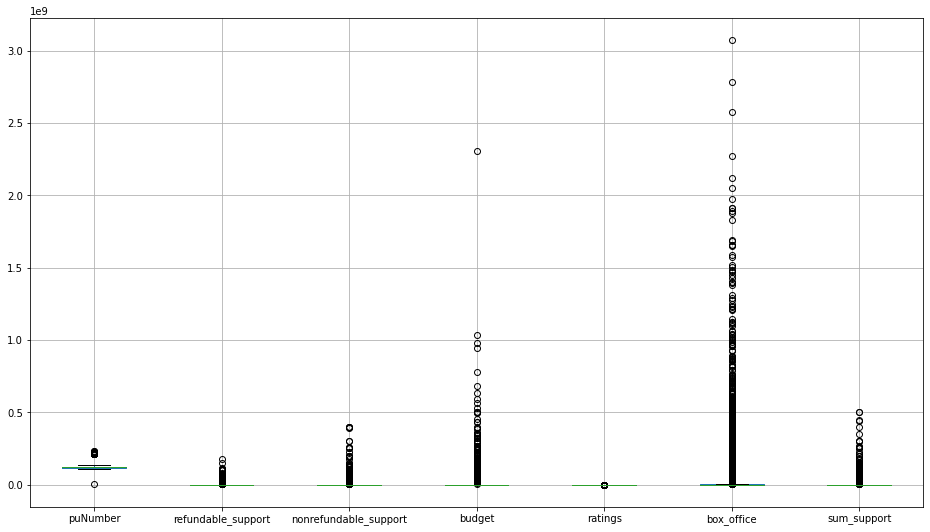

In [47]:
# Выводим на экран боксплот для всех количественных столбцов
df.boxplot(figsize=(16,9));

Почти не имеется тело боксплота для всех столбцов, кроме столбцов `puNumber` и `ratings`. Можно сделать вывод что не имеются данные для `Q1`, `Q2`, `Q3` в столбцах где тело боксплота очень маленькое. Следовательно, проблема именно в том, что мы из-за большого количества выбросов(аномальных значений) не можем рассмотреть `Q1`, `Q2`, `Q3`.

#### Добавим новые столбцы

In [48]:
# Создаём столбец с информацией о годе проката
df['show_start_year'] = df['show_start_date'].dt.year

- Создаём два столбца: с именем и фамилией главного режиссёра и основным жанром фильма. В столбцы войдут первые значения из списка режиссёров и жанров соответственно.

In [49]:
def cell_first_value(split_sign, value):
    return value.split(split_sign)[0]

In [50]:
# Создаем столбец c первым значением из списка жанров
df['main_genre'] = df['genres'].apply(lambda x: cell_first_value(',', x))

In [51]:
# Создаем столбец c первым значением из списка главного режиссёра
df['main_director'] = df['director'].apply(lambda x: cell_first_value(',', x))

In [52]:
# Создаем столбец который показывает какую долю от общего бюджета фильма составляет государственная поддержка.
df['support_share'] = df['sum_support'] / df['budget']
df[~df['support_share'].isna()]['support_share']

1281    0.333703
1448    0.700000
1498    0.612691
1524    0.690095
1792    0.624764
          ...   
7463    0.510204
7465    0.526316
7473    0.529661
7475    0.649998
7477    0.666012
Name: support_share, Length: 332, dtype: float64

## Исследовательский анализ данных

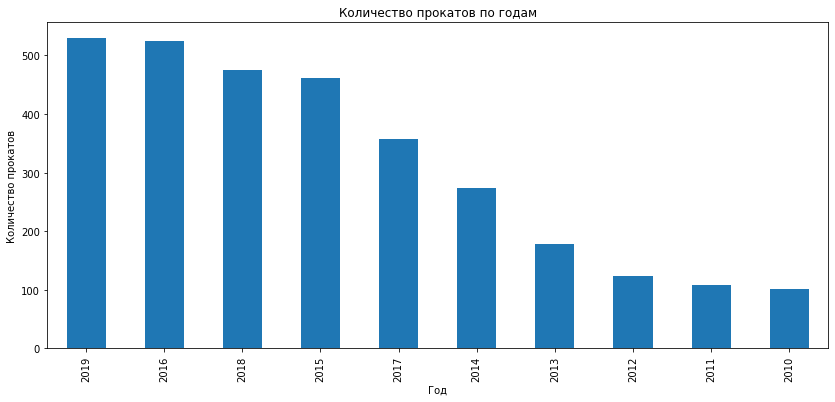

In [53]:
# Считаем сколько фильмов выходило на прокат каждый год
df[df['box_office'] != 0]['show_start_year'].value_counts().plot.bar(figsize=(14,6))
plt.title('Количество прокатов по годам')
plt.ylabel('Количество прокатов')
plt.xlabel('Год')
plt.show()

Самое большее количество фильмов которое выходило на прокат было в 2019 году более 500 фильмов. Самое меньшее количество было 2010 году менее 100 прокатов.

In [54]:
# Считаем в среднем сколько фильмов выходило на прокат каждый год
df[df['box_office'] != 0]['show_start_year'].value_counts().mean()

313.4

В среднем с 2010 года по 2019 год на прокат выходило 313 фильмов каждый год.

In [55]:
# Рассмотрим, какую долю составляют фильмы с указанной информацией о прокате в кинотеатрах.
len(df[df['box_office'] != 0])/len(df)

0.4187040748162993

42% составляют фильмы с указанной информацией о прокате в кинотеатрах.

In [56]:
# Меняем значение в столбце count_box_office
df['count_box_office'] = np.where(df['box_office'] != 0, 1, 0)

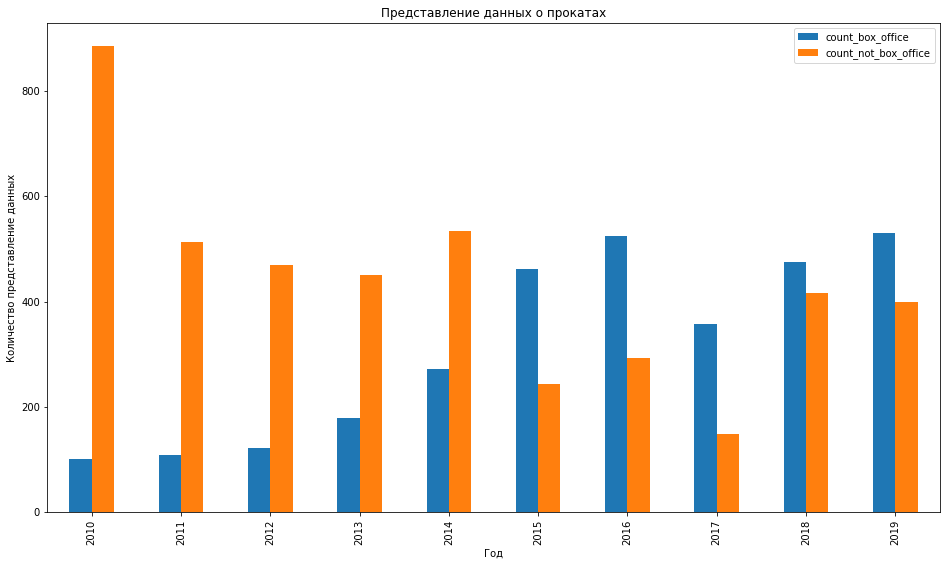

In [57]:
box_office_share = df.pivot_table(values='count_box_office', index='show_start_year', aggfunc=['sum', 'count']).reset_index()
box_office_share.columns = ['year', 'count_box_office', 'count_all']
box_office_share['count_not_box_office'] = box_office_share['count_all'] - box_office_share['count_box_office']
box_office_share.plot(x='year', y=['count_box_office', 'count_not_box_office'], kind='bar', figsize=(16,9))
plt.title('Представление данных о прокатах')
plt.ylabel('Количество представление данных')
plt.xlabel('Год')
plt.show()

Видно что в целом с каждым годом растёт представление данных о прокатах. Последние пять лет количество представленных данных больше чем не представленных.

- Изучим, как менялась динамика проката по годам. 
    - В каком году сумма сборов была минимальной? 
    - А максимальной?

In [58]:
# Фильтруем данные где столбец box_office не равно 0
box_office = df[~(df['box_office']==0)]

In [59]:
# Создаём сводную таблицу по годом 
sum_year = box_office.pivot_table(values='box_office', index='show_start_year', aggfunc=['sum'])
sum_year.columns = ['sum_box_office']
sum_year.reset_index(inplace=True)

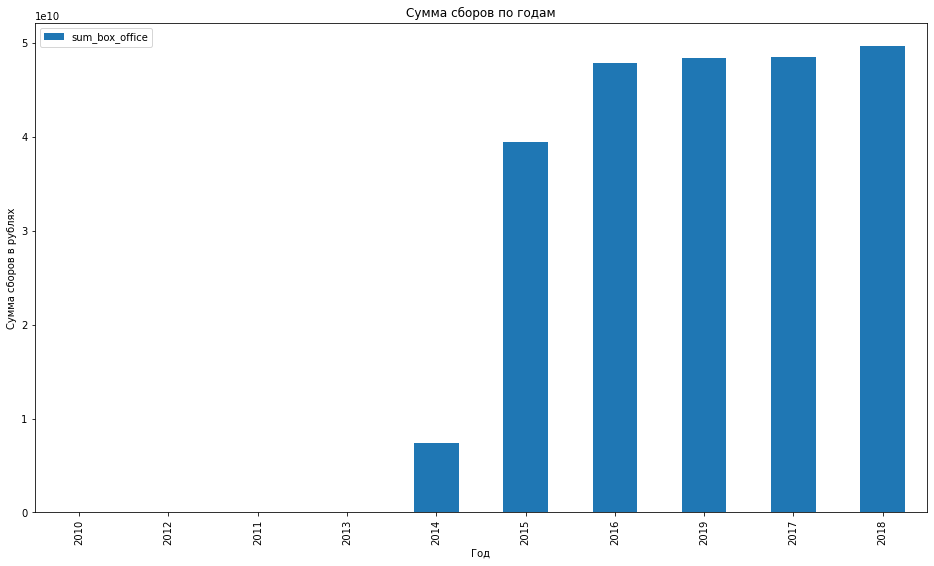

In [60]:
# Строим график по сумме сборов в рублях по годам
sum_year.sort_values('sum_box_office').plot(x='show_start_year', y='sum_box_office', kind='bar', figsize=(16,9))
plt.title('Сумма сборов по годам')
plt.ylabel('Сумма сборов в рублях')
plt.xlabel('Год')
plt.show()

In [61]:
sum_year.sort_values('sum_box_office')

,show_start_year,sum_box_office
0,2010,2.428654e+06
2,2012,6.955423e+06
1,2011,1.410276e+07
3,2013,2.979971e+07
4,2014,7.444952e+09
5,2015,3.949737e+10
6,2016,4.786630e+10
9,2019,4.842571e+10
7,2017,4.856371e+10
8,2018,4.966840e+10


В **2010** году было самое минимальное значение и в **2018** году было максимальное. С каждым годом сумма сборов увеличивается. В объемном исчислении сумма сборов имел колоссальный рост в 2014-2015 годах.

In [62]:
# Находим максимальное значение сборов
box_office[box_office['box_office']==box_office['box_office'].max()]

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,...,financing_source,ratings,genres,box_office,sum_support,show_start_year,main_genre,main_director,support_share,count_box_office
7455,Холоп,111021719,2019-12-19 12:00:00+00:00,Художественный,"ООО ""МЕМ-МЕДИА"" по заказу АО ""ВБД Груп""",Россия,К.Шипенко,"Э.Илоян, Д.Жалинский, В.Дусмухаметов, Т.Бадзие...",«12+» - для детей старше 12 лет,25000000.0,...,Фонд кино,6.8,комедия,3.073569e+09,60000000.0,2019,комедия,К.Шипенко,0.375,1


Максимальное значение сборов был 3.07 миллиардов рублей. Название фильма Холоп. Тип фильма Художественный. Вышел на прокат в 19 декабря 2019 года.

In [63]:
# Находим минимальное значение сборов
box_office[box_office['box_office']==box_office['box_office'].min()]

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,...,financing_source,ratings,genres,box_office,sum_support,show_start_year,main_genre,main_director,support_share,count_box_office
151,Жестокий романс,111006013,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Э.Рязанов,неизвестно,«12+» - для детей старше 12 лет,0.0,...,нет,8.1,"драма,мелодрама,история",40.0,0.0,2013,драма,Э.Рязанов,NaN,1


Минимальное значение сборов был 40 рублей. Название фильма Жестокий романс. Тип фильма Художественный. Вышел на прокат в 18 октября 2013 года. Очень странно что всего лишь 40 рублей.

In [64]:
# Выводим сводную таблицу
box_office.pivot_table(values='box_office', index='show_start_year', aggfunc=['max', 'min'])

,max,min
,box_office,box_office
show_start_year,,
2010,1.446400e+06,75.0
2011,1.161808e+07,125.0
2012,2.311220e+06,80.0
2013,1.995703e+07,40.0
2014,1.016411e+09,50.0
2015,1.658861e+09,100.0
2016,2.048126e+09,200.0
2017,2.779686e+09,7900.0


Сводная таблица показывает максимальное и минимальное значение суммы сборов определённого фильма по годам. Максимальные значения выглядят рациональным, в то время как минимальные значения выглядят спорным. 

In [65]:
# Считаем среднюю и медианную сумму сборов для каждого года с помощью сводной таблицы
box_office.pivot_table(values='box_office', index='show_start_year', aggfunc=['mean', 'median'])

,mean,median
,box_office,box_office
show_start_year,,
2010,2.404608e+04,1710.000
2011,1.293832e+05,3000.000
2012,5.654815e+04,6220.000
2013,1.664788e+05,3580.000
2014,2.727089e+07,20400.000
2015,8.549213e+07,5003450.150
2016,9.117390e+07,3915041.020
2017,1.360328e+08,9968340.000


Сводная таблица показывает среднюю и медианную сумму сборов для каждого года. Из таблицы видно что среднее и медиана сильно отличаются друг от друга, так как имеются большие выбросы в данных. Также данные распределены не нормально. Если бы данные были распределены нормально то среднее значение и медиана была бы равной.

В среднее значение суммы сборов с каждым годом растёт. Максимальное среднее значение, 136 миллионов рублей, было в 2017 году. Самое минимальное среднее значение, 24046 рублей, было в 2011 году. 

Медиана также становится больше с каждым годом. Медиана суммы сборов была максимальной в 2017 году и минимальной в 2010 году.

- Определим, влияет ли возрастное ограничение аудитории («6+», «12+», «16+», «18+» и т. д.) на сборы фильма в прокате в период с 2015 по 2019 год? 
- Фильмы с каким возрастным ограничением собрали больше всего денег в прокате? 
- Меняется ли картина в зависимости от года?

In [66]:
# Считаем среднее, медиану, сумму сборов относительно возрастных ограничении аудитории и каждого года
age_restriction = box_office.pivot_table(values='box_office', 
                       index=['age_restriction', 'show_start_year'], 
                       aggfunc=['mean', 'median', 'sum']).reset_index()
age_restriction.columns = ['age_restriction', 'show_start_year', 'mean', 'median', 'sum']

#  Сделаем  с 2015 по 2019 год
age_restriction = age_restriction[age_restriction['show_start_year'] >= 2015]

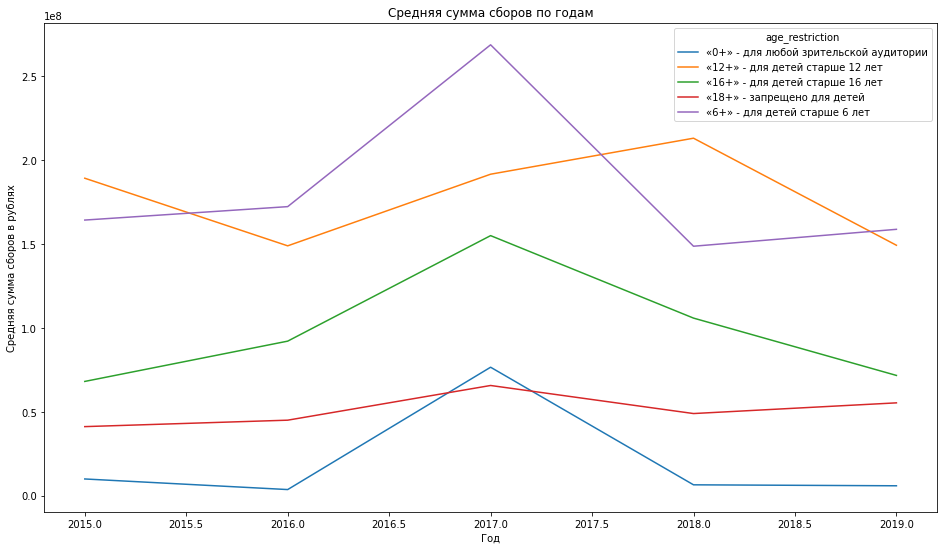

In [67]:
# Рисуем график используя seaborn библиотеку
sns.lineplot(data=age_restriction, x="show_start_year", y="mean", hue='age_restriction')
plt.gcf().set_size_inches(16,9)
plt.title('Средняя сумма сборов по годам')
plt.ylabel('Средняя сумма сборов в рублях')
plt.xlabel('Год')
plt.show()

График описывает как каждый год меняется средняя сумма сборов относительно возрастного ограничения. 6+ и 12+ показывают лучшие результаты в среднем, а худшим результатом является с возрастным ограничением 0+ фильмы. С 2015 года по 2017 год средняя сумма сборов увеличивался и достиг максимума, а потом пошел на спад.

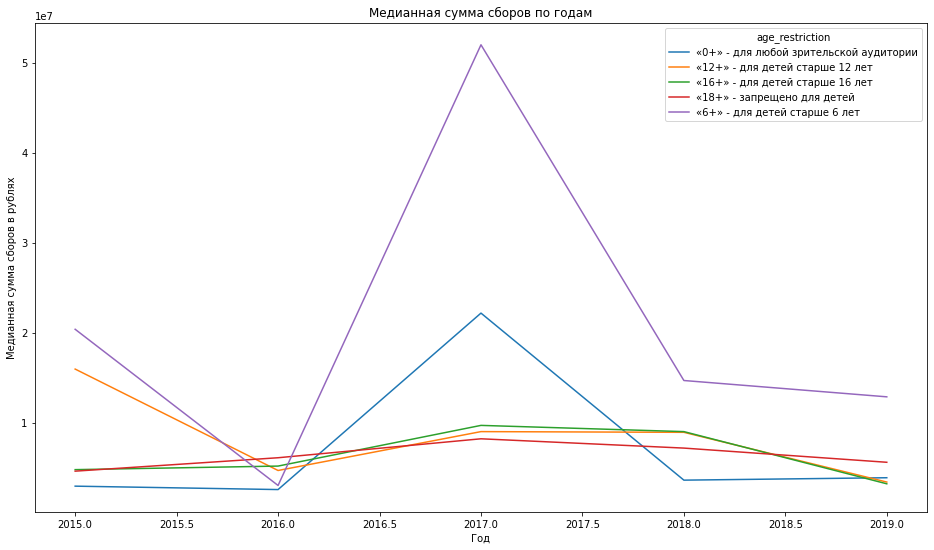

In [68]:
# Рисуем график используя seaborn библиотеку
sns.lineplot(data=age_restriction, x="show_start_year", y="median", hue='age_restriction')
plt.gcf().set_size_inches(16,9)
plt.title('Медианная сумма сборов по годам')
plt.ylabel('Медианная сумма сборов в рублях')
plt.xlabel('Год')
plt.show()

График описывает как каждый год меняется медиана суммы сборов относительно возрастного ограничения. Максимальная медиана суммы сборов у 6+ категории потом идет категория 0+, после категория 16+. Медиана говорит что каждый год 50% суммы сборов была больше чем сумма которая показана на графика.

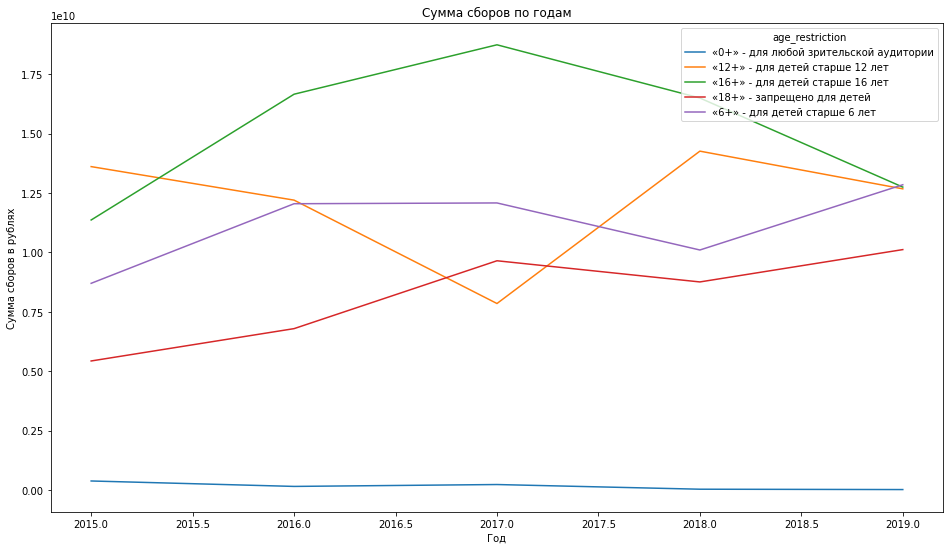

In [69]:
# Рисуем график используя seaborn библиотеку
sns.lineplot(data=age_restriction, x="show_start_year", y="sum", hue='age_restriction')
plt.gcf().set_size_inches(16,9)
plt.title('Сумма сборов по годам')
plt.ylabel('Сумма сборов в рублях')
plt.xlabel('Год')
plt.show()

Фильмы с возрастным ограничением 16+ собрали больше всего денег в прокате. Самое минимальную сумму собрали с возрастным ограничением 0+.

## Исследование фильмов, которые получили государственную поддержку

In [70]:
# Считаем среднюю сумму средств на поддержку кино для каждого года с помощью сводной таблицы
sum_support = box_office[box_office['sum_support']>0].pivot_table(values='sum_support', 
                       index=['show_start_year'], 
                       aggfunc='mean').reset_index()

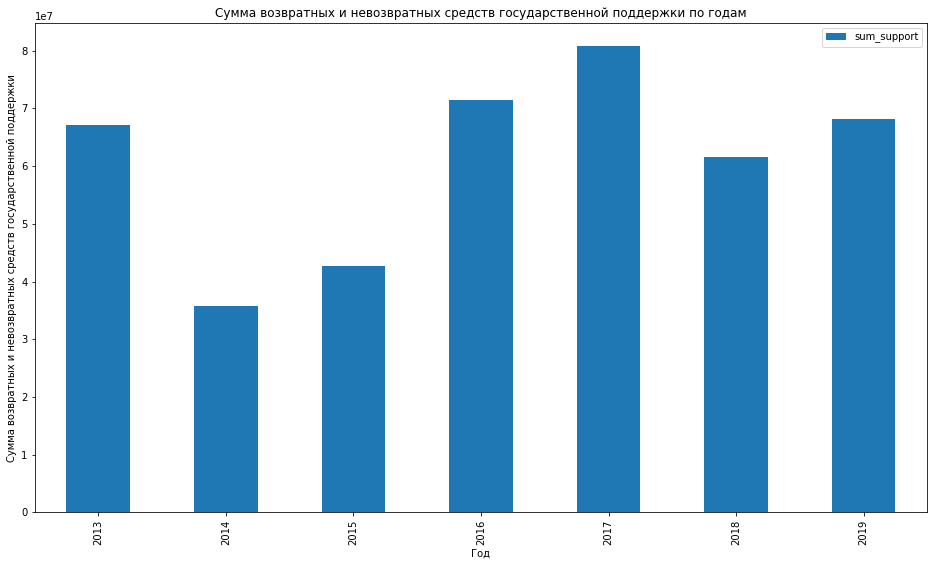

In [71]:
# Строим столбчатую диаграмму 
sum_support.plot(x='show_start_year', y='sum_support', kind='bar', figsize=(16,9))
plt.title('Сумма возвратных и невозвратных средств государственной поддержки по годам')
plt.ylabel('Сумма возвратных и невозвратных средств государственной поддержки')
plt.xlabel('Год')
plt.show()

График показывает сколько в среднем выделяются средств на поддержку кино каждый год. Максимальное выделенное средство было в 2017 году со значением в более 80 миллионов рублей в среднем. Минимальное значение было в 2014 году менее 35 миллионов рублей. В целом динамика роста за последние 5 лет с 2015 по 2019 года, стабильная, в среднем 6-7 миллионов рублей.

In [72]:
# Считаем среднюю сумму сборов для каждого года с помощью сводной таблицы
box_office_sum = box_office[box_office['sum_support']>0].pivot_table(values='box_office',   # код ревьюера, добавила фильтр гос поддержки [box_office['sum_support']>0]
                       index=['show_start_year'], 
                       aggfunc='mean').reset_index()

In [73]:
# Считаем средний рейтинг кино для каждого года с помощью сводной таблицы
ratings = box_office[box_office['sum_support']>0].pivot_table(values='ratings', # код ревьюера, добавила фильтр гос поддержки [box_office['sum_support']>0]
                       index=['show_start_year'], 
                       aggfunc='mean').reset_index()

In [74]:
# Объединяем две таблицы
box_office_rating = box_office_sum.merge(ratings, on='show_start_year')

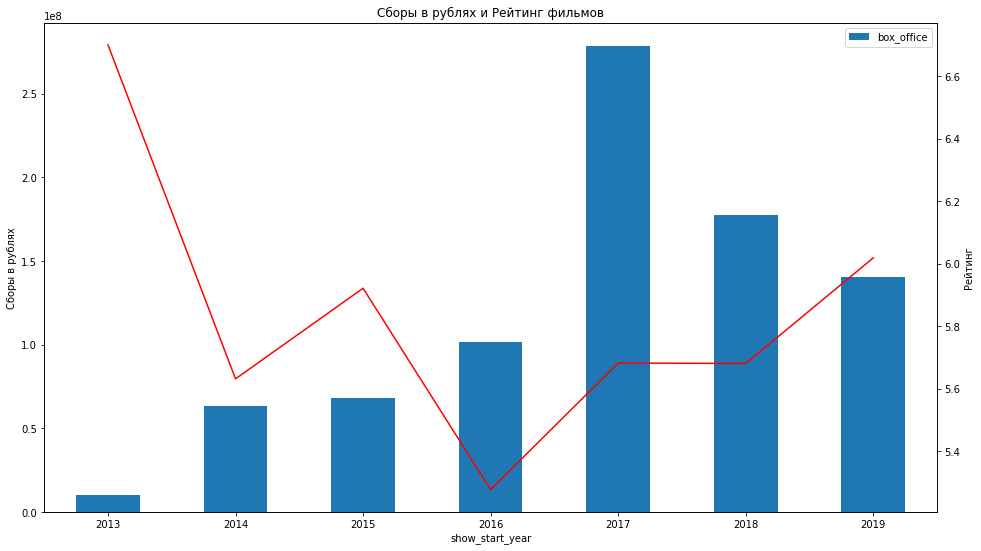

In [75]:
# Рисуем графику
ax1=box_office_rating.plot(x="show_start_year", y="box_office", kind='bar', figsize=(16,9));
ax2=box_office_rating['ratings'].plot(secondary_y=True, color='r');
ax1.set_ylabel('Сборы в рублях');
ax2.set_ylabel('Рейтинг');
plt.title('Сборы в рублях и Рейтинг фильмов')
plt.show()

График показывает по левой оси сборы прокатов в рублях (синий цвет), и по правой оси рейтинг фильмов (красный цвет). Особого тренда или взаимосвязи между двумя параметрами не имеется.

In [76]:
# Соединяем две таблицы 
box_office_support = box_office_sum.merge(sum_support, on='show_start_year')

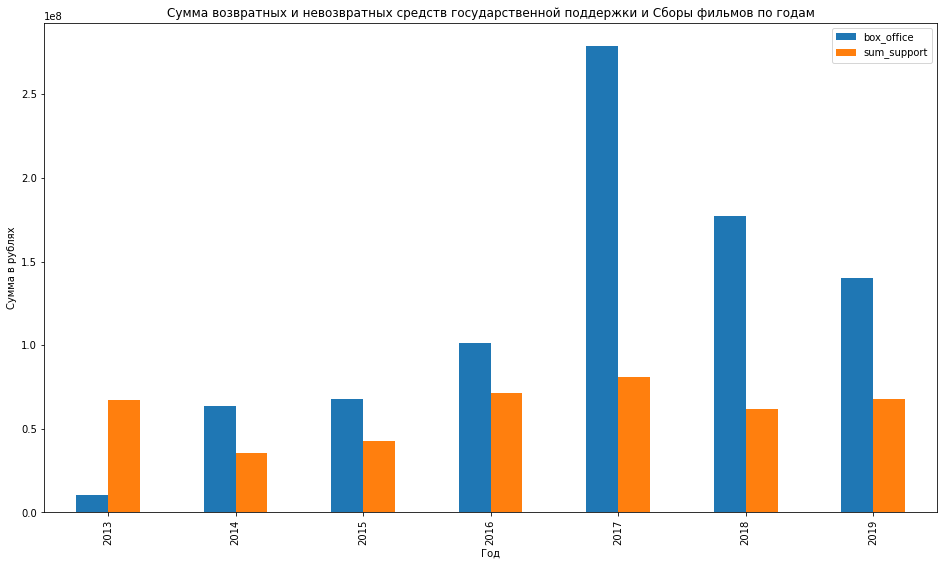

In [77]:
# Рисуем график
box_office_support.plot(x="show_start_year", kind="bar", figsize=(16,9))
plt.title('Сумма возвратных и невозвратных средств государственной поддержки и Сборы фильмов по годам')
plt.ylabel('Сумма в рублях')
plt.xlabel('Год')
plt.show()

На графике показан ежегодная сумма сборов в прокатах синим цветом и ежегодная сумма средств на поддержку кино оранжевым цветом. Особого тренда или взаимосвязи между двумя параметрами нет.

In [78]:
# Считаем среднию бюджета фильма за каждый год 
budget = df.pivot_table(values='budget', 
                       index=['show_start_year'], 
                       aggfunc='mean').reset_index()

In [79]:
# Соединяем две таблицы 
box_office_budget = box_office_sum.merge(budget, on='show_start_year')

In [80]:
# код ревьюера, мы все таблицы должны рассчитывать по одному фильтру. Если рассматриваем гос.поддержку, то везде нужно фильтровать по гос. поддержке. 
budget = box_office[box_office['sum_support']>0].pivot_table(values='budget', 
                       index=['show_start_year'], 
                       aggfunc='mean').reset_index()
box_office_budget = box_office_sum.merge(budget, on='show_start_year')

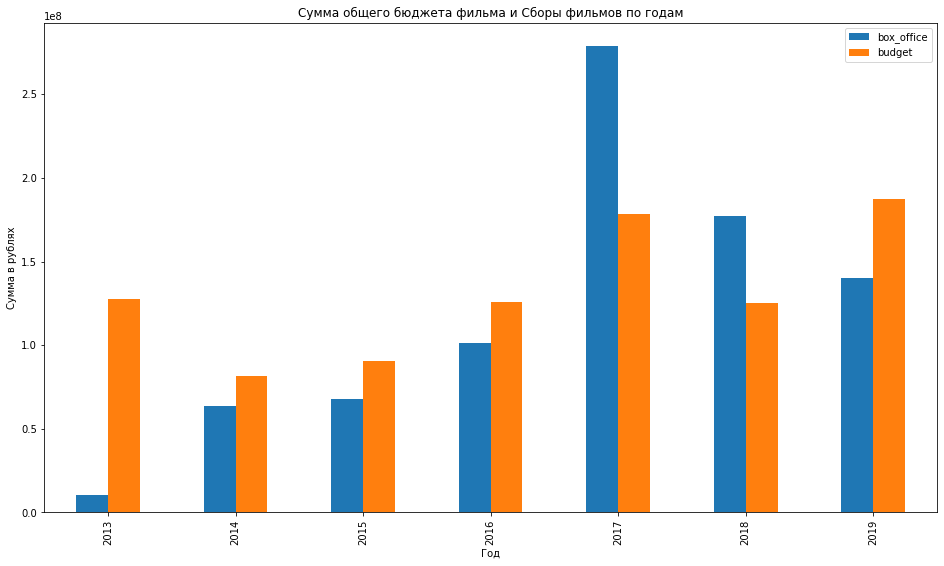

In [81]:
# Рисуем график
box_office_budget.plot(x="show_start_year", kind="bar", figsize=(16,9))
plt.title('Сумма общего бюджета фильма и Сборы фильмов по годам')
plt.ylabel('Сумма в рублях')
plt.xlabel('Год')
plt.show()

На графике показан ежегодная сумма сборов фильмов в рублях синим цветом и сумма бюджета фильмов в рублях оранжевым цветом. Взаимосвязь не имеется между двумя параметрами.

## Общий вывод

- Были проверены типы данных в датафрейме и преобразованы там, где это необходимо.
- Был проведён описание данных
- Были определённым образом заполнены пропуски для каждого столбца.
- Были проверены, есть ли в данных дубликаты. Вывод в том что если удалеям столбцы show_start_date, puNumber то в данных 484 дубликатов.
- Были изучины категориальные значения, и исправлены проблемные значения в поле type. Были удалены все пробелы, которые встречаются в начале и в конце строки во всех категориальных столбцах.
- Были проверены количественные значения в столбце `budget`. Имеются 16 фильмов у которых общий бюджет фильма равен нулю, скорее всего это были пустые строки, и являются ошибками в сборке данных. Как вариант можем заполнить эти нули с суммой возвратных и невозвратных средств государственной поддержки.
- Был создан столбец с информацией о годе проката. Также создали два столбца: с именем и фамилией главного режиссёра и основным жанром фильма. В столбцы вошли первые значения из списка режиссёров и жанров соответственно.

**Был проведен исследовательский анализ данных. Выводы:**

- Самое большее количество фильмов которое выходило на прокат было в 2019 году более 500 фильмов. Самое меньшее количество было 2010 году менее 100 прокатов.
- В целом с каждым годом растёт представление данных о прокатах. Последние пять лет количество представленных данных больше чем не представленных.
- В 2010 году было самое минимальное значение и в 2018 году было максимальное. С каждым годом сумма сборов увеличивается. В объемном исчислении сумма сборов имел колоссальный рост в 2014-2015 годах.
- Максимальное значение сборов был 3.07 миллиардов рублей. Название фильма Холоп. Тип фильма Художественный. Вышел на прокат в 19 декабря 2019 года.
- Минимальное значение сборов был 40 рублей. Название фильма Жестокий романс. Тип фильма Художественный. Вышел на прокат в 18 октября 2013 года. Очень странно что всего лишь 40 рублей.
- Среднее и медиана сильно отличаются друг от друга, так как имеются большие выбросы в данных. Также данные распределены не нормально. Если бы данные были распределены нормально то среднее значение и медиана была бы равной.
- В среднее значение суммы сборов с каждым годом растёт. Максимальное среднее значение, 136 миллионов рублей, было в 2017 году. Самое минимальное среднее значение, 24046 рублей, было в 2011 году.
- Медиана также становится больше с каждым годом. Медиана суммы сборов была максимальной в 2017 году и минимальной в 2010 году.
- 6+ и 12+ показывают лучшие результаты в среднем, а худшим результатом является с возрастным ограничением 0+ фильмы. С 2015 года по 2017 год средняя сумма сборов увеличивался и достиг максимума, а потом пошел на спад.
- Максимальная медиана суммы сборов у 6+ категории потом идет категория 0+, после категория 16+. Медиана говорит что каждый год 50% суммы сборов была больше чем сумма которая показана на графика.
- Фильмы с возрастным ограничением 16+ собрали больше всего денег в прокате. Самое минимальную сумму собрали с возрастным ограничением 0+.
- Максимальное выделенное средство было в 2017 году со значением в более 80 миллионов рублей в среднем. Минимальное значение было в 2014 году менее 35 миллионов рублей. В целом динамика роста за последние 5 лет с 2015 по 2019 года, стабильная, в среднем 6-7 миллионов рублей.
- Взаимосвязи между двумя параметрами, сборы фильмов в рублях и рейтинг фильмов не имеется.
- Взаимосвязи между двумя параметрами, сборы фильмов в рублях и сумма средств на поддержку кино не имеется.
- Взаимосвязи между двумя параметрами, сборы фильмов в рублях и сумма бюджета фильмов в рублях не имеется.